In [1]:
import scipy as sp
from scipy.fft import fft, ifft
from scipy.integrate import quad
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, heaviside, exp, sin, cos
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime, e_r_recursive_cpa
import warnings
warnings.filterwarnings('ignore')

## This notebook concerns the paper [Causality relations in the homogenization of metamaterials](https://journals.aps.org/prb/pdf/10.1103/PhysRevB.84.054305?casa_token=4f21nymi9rIAAAAA%3AFQXPLXASOiUj-PXAmIum1JlwFggxSD5gFvi7e0Wx836uvSvYz3iwo8bwIpZZoSLACPKvtWAog3tjyg) by Andrea Alu

### We first do Figure 1

In [2]:
# We define alpha_s (which is actually a^(-3)alpha_s), where alpha_s is defined in Equation 15 of the paper
# Note that k_0 here is actually the dimensionless quantity k_0a
def alpha_s(k_0, x):
    return ((6*pi)/k_0**3)/(1/(k_0*x)**3-1j)

# We define alpha_d (which is actually alpha_d/a^3), where alpha_d is the fully retarded polarizability, defined in Equation 7 of the paper
def alpha_d(k_0, epsilon):
    k = k_0*sqrt(epsilon)
    k0j_lprime = spherical_jn(1, k_0) + k_0*spherical_jn(1, k_0, derivative = True)
    k0y_lprime = spherical_yn(1, k_0) + k_0*spherical_yn(1, k_0, derivative = True)
    kj_lprime = spherical_jn(1, k) + k*spherical_jn(1, k, derivative = True)

    u = spherical_jn(1, k)*k0j_lprime - spherical_jn(1, k_0)*kj_lprime/epsilon
    v = spherical_jn(1, k)*k0y_lprime - spherical_yn(1, k_0)*kj_lprime/epsilon
    return (6*pi/k_0**3)/(v/u-1j)

# alpha_s in the time domain (normalized by 2*pi*c*x^2*a^2 in accordance with Figure 2)
# Note that t here is actually the dimensionless quantity ct/2a
def alpha_st(t, x):
    causal_component = exp(-t/x)*(cos(sqrt(3)*t/x) + sqrt(3)*sin(sqrt(3)*t/x))
    non_causal_component = exp(2*t/x)
    return heaviside(t, 0.5)*causal_component + heaviside(-t, 0.5)*non_causal_component

# returns x, as defined in the paper (we take epsilon_0=1)
def return_x(epsilon):
    x_cubed = (2/3)*(epsilon-1)/(epsilon+2)
    return x_cubed**(1/3)

In [3]:
epsilon_1 = 3
epsilon_2 = 20
x_1 = return_x(epsilon_1)
x_2 = return_x(epsilon_2) # These are the two values used in Figure 1

In [4]:
N = 10000
k_0_s = linspace(0.01, 8, N)
alpha_s_1 = alpha_s(k_0_s, x_1)
alpha_s_2 = alpha_s(k_0_s, x_2)

alpha_d_1 = alpha_d(k_0_s, epsilon_1)
alpha_d_2 = alpha_d(k_0_s, epsilon_2)

print("Max Re(alpha_s_1): ", alpha_s_1.real.max().round(3))
print("Max Im(alpha_s_1): ", alpha_s_1.imag.max().round(3))
print("Max Re(alpha_s_2): ", alpha_s_2.real.max().round(3))
print("Max Im(alpha_s_2): ", alpha_s_2.imag.max().round(3))

Max Re(alpha_s_1):  5.027
Max Im(alpha_s_1):  2.513
Max Re(alpha_s_2):  10.853
Max Im(alpha_s_2):  5.426


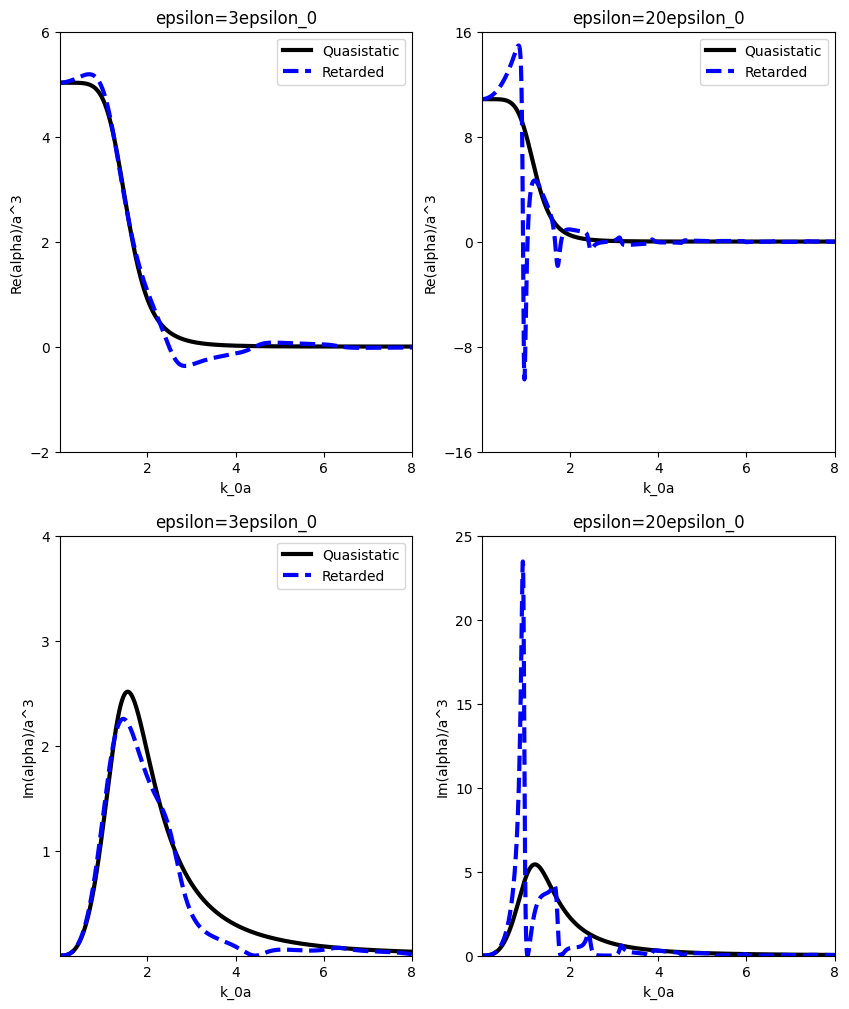

In [5]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 12))
ax1.plot(k_0_s, alpha_s_1.real, color="black", linewidth=3, label="Quasistatic")
ax1.plot(k_0_s, alpha_d_1.real, color="blue", linewidth=3, linestyle="dashed", label="Retarded")
ax1.legend()
ax1.set_xlim(k_0_s.min(), k_0_s.max());
ax1.set_ylim(-2, 6);
ax1.set_xticks(linspace(2, 8, 4));
ax1.set_yticks(linspace(-2, 6, 5));
ax1.set_title("epsilon=3epsilon_0")
ax1.set_xlabel("k_0a")
ax1.set_ylabel("Re(alpha)/a^3")

ax2.plot(k_0_s, alpha_s_2.real, color="black", linewidth=3, label="Quasistatic")
ax2.plot(k_0_s, alpha_d_2.real, color="blue", linewidth=3, linestyle="dashed", label="Retarded")
ax2.legend()
ax2.set_xlim(k_0_s.min(), k_0_s.max());
ax2.set_ylim(-16, 16)
ax2.set_xticks(linspace(2, 8, 4));
ax2.set_yticks(linspace(-16, 16, 5))
ax2.set_title("epsilon=20epsilon_0");
ax2.set_xlabel("k_0a");
ax2.set_ylabel("Re(alpha)/a^3")

ax3.plot(k_0_s, alpha_s_1.imag, color="black", linewidth=3, label="Quasistatic")
ax3.plot(k_0_s, alpha_d_1.imag, color="blue", linewidth=3, linestyle="dashed", label="Retarded")
ax3.legend();
ax3.set_xlim(k_0_s.min(), k_0_s.max());
ax3.set_ylim(0, 4);
ax3.set_yticks(linspace(1, 4, 4))
ax3.set_xticks(linspace(2, 8, 4));
ax3.set_xlabel("k_0a")
ax3.set_ylabel("Im(alpha)/a^3")
ax3.set_title("epsilon=3epsilon_0")

ax4.plot(k_0_s, alpha_s_2.imag, color="black", linewidth=3, label="Quasistatic")
ax4.plot(k_0_s, alpha_d_2.imag, color="blue", linewidth=3, linestyle="dashed", label="Retarded")
ax4.set_ylim(0, 25)
ax4.set_xlim(k_0_s.min(), k_0_s.max());
ax4.set_xticks(linspace(2, 8, 4));
ax4.set_xlabel("k_0a");
ax4.set_ylabel("Im(alpha)/a^3")
ax4.set_title("epsilon=20epsilon_0");

### Now we do Figure 2

In [6]:
N = 10000
t_s = linspace(-2, 10, N) # range of time for Figure 2
alpha_st_1 = alpha_st(t_s, x_1);
alpha_st_2 = alpha_st(t_s, x_2);
print("Max value of alpha_st_1: ", alpha_st_1.max().round(3))
print("Min value of alpha_st_1: ", alpha_st_1.min().round(3))
print("Max value of alpha_st_2: ", alpha_st_2.max().round(3))
print("Min value of alpha_st_2: ", alpha_st_2.min().round(3))

Max value of alpha_st_1:  1.28
Min value of alpha_st_1:  -0.209
Max value of alpha_st_2:  1.28
Min value of alpha_st_2:  -0.209


We now implement the Fourier transform explicitly. Although this is not necessary for the quasistatic susceptibility (since, as we have already shown, the Fourier transform of the quasistatic polarizability may be found in closed form), we must resort to numerics for the fully retarded polarizability (and we use the closed form quasistatic polarizability to sanity check that our numerics are valid). Note that scipy's fft function is defined as: $\tilde{f}(m)=\sum_{n}e^{-2\pi i nm/N}f(n)=\sum_{n}e^{-i(2\pi n/T) (m/N)T}f(n)= (T/(2\pi))\int_0^{2\pi N/T} e^{-i\omega (mT/N)} f(\omega)\text{d}\omega$, where in the second equality all we did was multiply and divide by the same factor, $T$. In the third equality, we noted that the spacing of the elements in the sum is $2\pi/T$ to convert the sum to an integral. What we want to calculate is actually $\frac{1}{\pi}\Re\Bigg[\int_0^\infty e^{-i\omega t}f(\omega)\text{d}\omega\Bigg]$. Note that the polarizability is given as a function of $\tilde{k}=(a\omega/c)$, where we define $\tilde{k}\equiv ka$. Therefore, we may write the Fourier transform as $\frac{c}{a\pi}\Re\Bigg[\int_0^\infty e^{-i \tilde{k}\tilde{t}}f(\tilde{k})\text{d}\tilde{k}\Bigg]$, where we define $\tilde{t}\equiv(ct/a)$. Therefore, $\alpha(\tilde{t})=(2c/aT)\text{fft}[\alpha_\omega]$. In the end, we want to plot the quantity $\alpha(\tilde{t})/(2\pi cx^2a^2)$. We need not worry about the two factors of $a$ in this expression since we implicitly took care of that in how the function $\alpha_s(k_0)$ was defined.

In [68]:
T = 3000 # total normalized time (ct/a)
N = 1000000 
k_0_s = 2*pi*linspace(1, N, N)/T
t_s_numerical = linspace(1, N, N)*T/N
alpha_s_1 = alpha_s(k_0_s, x_1)
alpha_s_2 = alpha_s(k_0_s, x_2)

alpha_d_1 = alpha_d(k_0_s, epsilon_1)
alpha_d_2 = alpha_d(k_0_s, epsilon_2)

t_0 = -6 # Normalized Starting time in units of $ct/a$
to_negative_times = exp(-1j*k_0_s*t_0)

alpha_s_t_1_numerical = fft(alpha_s_1 * to_negative_times).real/(pi*T*x_1**2);
alpha_s_t_2_numerical = fft(alpha_s_2 * to_negative_times).real/(pi*T*x_2**2);

alpha_d_t_1_numerical = fft(alpha_d_1 * to_negative_times).real/(pi*T*x_1**2);
alpha_d_t_2_numerical = fft(alpha_d_2 * to_negative_times).real/(pi*T*x_2**2);

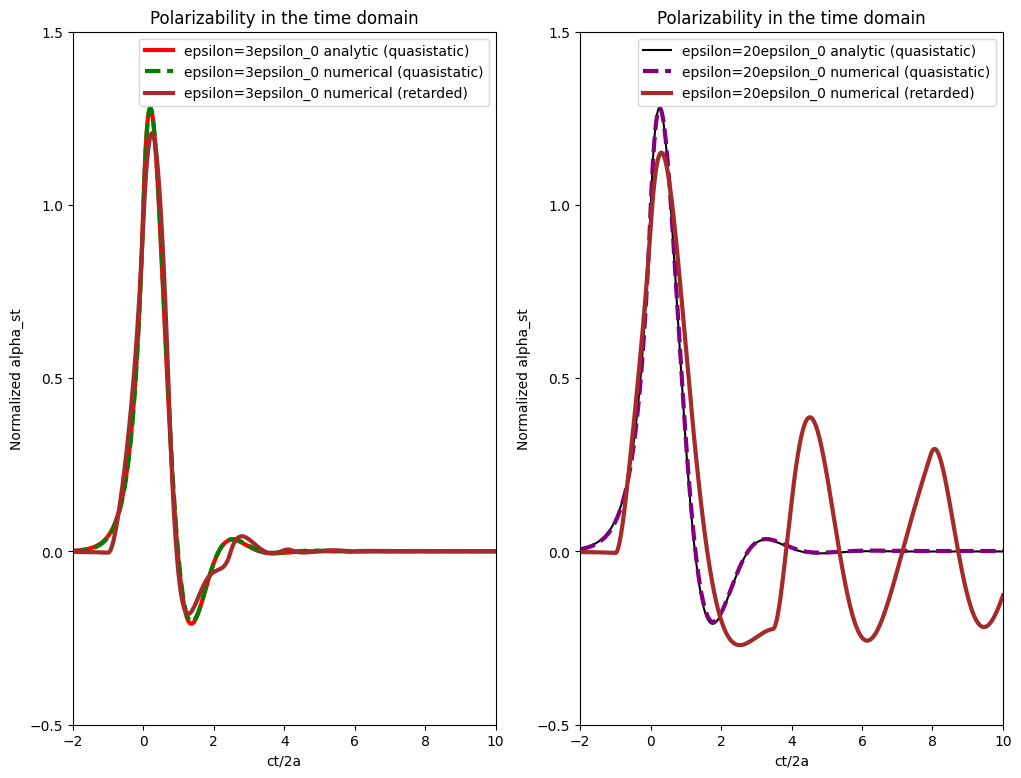

In [75]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 9))

ax1.plot(t_s, alpha_st_1, color="red", label="epsilon=3epsilon_0 analytic (quasistatic)", linewidth=3)
ax1.plot(t_s_numerical/2+t_0/2, alpha_s_t_1_numerical, color="green", linestyle="dashed", linewidth=3, label="epsilon=3epsilon_0 numerical (quasistatic)")
ax1.plot(t_s_numerical/2+t_0/2, alpha_d_t_1_numerical, color="brown", linewidth=3, label="epsilon=3epsilon_0 numerical (retarded)")

ax2.plot(t_s, alpha_st_2, color="black", label="epsilon=20epsilon_0 analytic (quasistatic)");
ax2.plot(t_s_numerical/2+t_0/2, alpha_s_t_2_numerical, color="purple", linestyle="dashed", linewidth=3, label="epsilon=20epsilon_0 numerical (quasistatic)")
ax2.plot(t_s_numerical/2+t_0/2, alpha_d_t_2_numerical, color="brown", linewidth=3, label="epsilon=20epsilon_0 numerical (retarded)")

ax1.legend();
ax1.set_xlim(t_s.min(), t_s.max());
ax1.set_yticks(linspace(-0.5, 1.5, 5))
ax1.set_ylim(-0.5, 1.5);
ax1.set_xlabel("ct/2a")
ax1.set_ylabel("Normalized alpha_st");
ax1.set_title("Polarizability in the time domain");

ax2.legend();
ax2.set_xlim(t_s.min(), t_s.max());
ax2.set_yticks(linspace(-0.5, 1.5, 5))
ax2.set_ylim(-0.5, 1.5);
ax2.set_xlabel("ct/2a")
ax2.set_ylabel("Normalized alpha_st");
ax2.set_title("Polarizability in the time domain");

### Figure 3: Generalized Kramers-Kronig Relations

### We write out a generalized version of the Kramers-Kronig relations for functions that are (almost) causal. We have: 

$\alpha'(\omega)=\frac{1}{\pi}P\int_{-\infty}^\infty\frac{\alpha''(\Omega)}{\Omega-\omega}\text{d}\Omega$

In [122]:
min_int_range = 0.01
max_int_range = 10
kk_results_1 = []
kk_results_2 = []

original_alpha_d_results_1 = []
original_alpha_d_results_2 = []

N = 1000
k_0_s = linspace(0.02, 8, N)
for (k_0_idx, k_0_eval) in enumerate(k_0_s):
    if (k_0_idx % 50) == 0:
        print("k_0_idx: ", k_0_idx)
    positive_integral = quad(lambda k_0: alpha_d(k_0, epsilon_1).imag, min_int_range, max_int_range, wvar = k_0_eval, weight="cauchy")[0]
    negative_integral = quad(lambda k_0: -alpha_d(-k_0, epsilon_1).imag, -max_int_range, -min_int_range, wvar = k_0_eval, weight="cauchy")[0]
    result = (positive_integral + negative_integral)/pi
    kk_results_1.append(result)

    positive_integral = quad(lambda k_0: alpha_d(k_0, epsilon_2).imag, min_int_range, max_int_range, wvar = k_0_eval, weight="cauchy")[0]
    negative_integral = quad(lambda k_0: -alpha_d(-k_0, epsilon_2).imag, -max_int_range, -min_int_range, wvar = k_0_eval, weight="cauchy")[0]
    result = (positive_integral + negative_integral)/pi
    kk_results_2.append(result)

    original_alpha_d_results_1.append(alpha_d(k_0_eval, epsilon_1).real)
    original_alpha_d_results_2.append(alpha_d(k_0_eval, epsilon_2).real)



k_0_idx:  0
k_0_idx:  50
k_0_idx:  100
k_0_idx:  150
k_0_idx:  200
k_0_idx:  250
k_0_idx:  300
k_0_idx:  350
k_0_idx:  400
k_0_idx:  450
k_0_idx:  500
k_0_idx:  550
k_0_idx:  600
k_0_idx:  650
k_0_idx:  700
k_0_idx:  750
k_0_idx:  800
k_0_idx:  850
k_0_idx:  900
k_0_idx:  950


### In the below, we define new sets of arrays with the corrected Kramers-Kronig relations, following Equation 24 of the paper

In [123]:
generalized_kk_results_1 = kk_results_1 + (4*pi*x_1**3)/(1+(x_1*k_0_s)**2)
generalized_kk_results_2 = kk_results_2 + (4*pi*x_2**3)/(1+(x_2*k_0_s)**2)

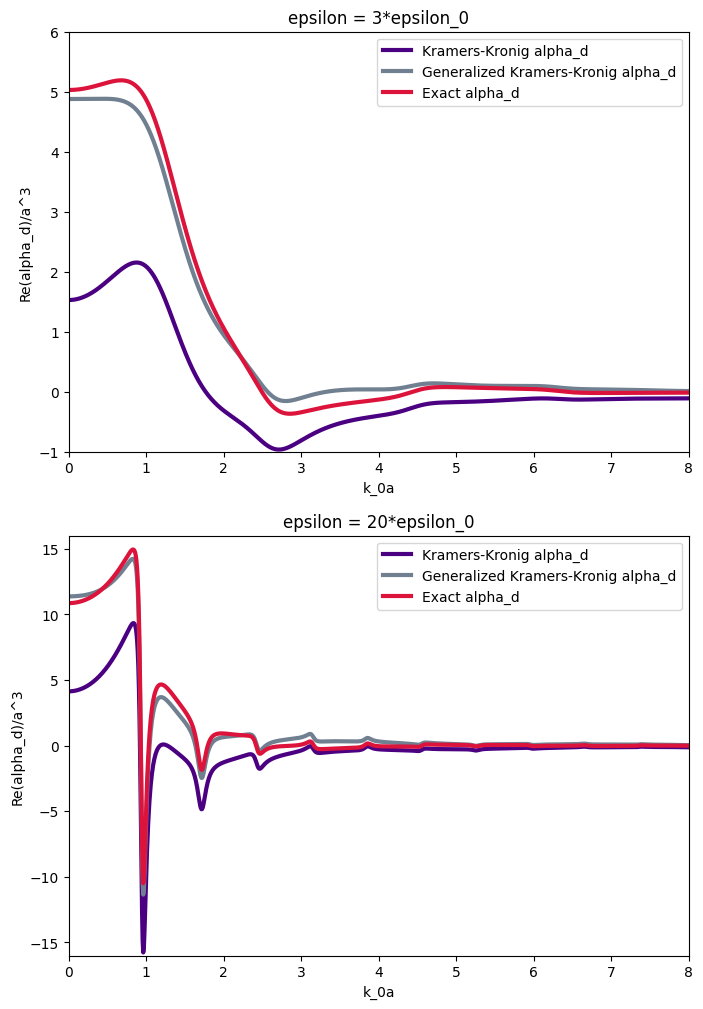

In [125]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))
ax1.plot(k_0_s, kk_results_1, color="indigo", linewidth=3, label="Kramers-Kronig alpha_d")
ax1.plot(k_0_s, generalized_kk_results_1, color="slategray", linewidth=3, label="Generalized Kramers-Kronig alpha_d")
ax1.plot(k_0_s, original_alpha_d_results_1, color="crimson", linewidth=3, label="Exact alpha_d")
ax1.set_xlim(0, 8)
ax1.set_ylim(-1, 6);
ax1.set_title("epsilon = 3*epsilon_0")
ax1.set_xlabel("k_0a")
ax1.set_ylabel("Re(alpha_d)/a^3")
ax1.legend();

ax2.plot(k_0_s, kk_results_2, color="indigo", linewidth=3, label="Kramers-Kronig alpha_d")
ax2.plot(k_0_s, generalized_kk_results_2, color="slategray", linewidth=3, label="Generalized Kramers-Kronig alpha_d")
ax2.plot(k_0_s, original_alpha_d_results_2, color="crimson", linewidth=3, label="Exact alpha_d")
ax2.set_xlim(0, 8)
ax2.set_ylim(-16, 16);
ax2.set_title("epsilon = 20*epsilon_0")
ax2.set_xlabel("k_0a")
ax2.set_ylabel("Re(alpha_d)/a^3")
ax2.legend();